<div style="
background: linear-gradient(135deg,#e0f2fe,#dbeafe,#bfdbfe);
padding:35px;
border-radius:20px;
border:2px solid #3b82f6;
box-shadow:0 8px 25px rgba(0,0,0,0.15);
color:#111827;
">

<h1 style="
text-align:center;
font-size:42px;
margin-bottom:10px;
color:#1e3a8a;
">
🩻 Pneumonia Chest X-Ray Classification System
</h1>

<h3 style="
text-align:center;
color:#2563eb;
margin-top:5px;
">
PRAICP-1012 | Deep Learning & Medical AI
</h3>

<hr style="
border:1px solid #93c5fd;
">

<table style="
width:100%;
font-size:17px;
border-collapse:collapse;
color:#111827;
">

<tr>

<td style="padding:15px;">
<b style="color:#dc2626;">👩‍💻 Developed By:</b><br>
P Shabreen Taj
</td>

<td style="padding:15px;">
<b style="color:#059669;">🏥 Domain:</b><br>
Healthcare AI
</td>

</tr>

<tr>

<td style="padding:15px;">
<b style="color:#7c3aed;">📊 Dataset:</b><br>
Chest X-Ray Images
</td>

<td style="padding:15px;">
<b style="color:#ea580c;">🎯 Objective:</b><br>
Detect Pneumonia
</td>

</tr>

<tr>

<td style="padding:15px;">
<b style="color:#0284c7;">🤖 Models:</b><br>
Custom CNN + EfficientNetB0
</td>

<td style="padding:15px;">
<b style="color:#be123c;">🚀 Goal:</b><br>
Early Pneumonia Detection
</td>

</tr>

</table>

</div>

<br>

<div style="
background:#f8fafc;
padding:20px;
border-left:6px solid #2563eb;
border-radius:10px;
color:#111827;
">

<h3 style="color:#1e40af;">
📌 Executive Summary
</h3>

This project develops a <b>Deep Learning based medical imaging system</b> capable of automatically detecting <b>Pneumonia</b> from Chest X-Ray images.

The solution leverages <b>Convolutional Neural Networks (CNN)</b> and <b>Transfer Learning</b> techniques to classify chest radiographs into:

<ul>
<li>✅ NORMAL</li>
<li>🚨 PNEUMONIA</li>
</ul>

The developed system aims to assist healthcare professionals through faster screening, improved diagnostic support, and early disease detection.

</div>

# 🏥 Business Problem

Pneumonia is one of the leading causes of death worldwide, especially among children and elderly patients.

Traditional diagnosis using chest X-ray images requires expert radiologists and can be time-consuming.

The objective of this project is to build an Artificial Intelligence based medical imaging system capable of automatically detecting Pneumonia from chest X-ray images.

---

# 🎯 Project Goal

Develop a Deep Learning model that can classify chest X-ray images into:

- ✅ NORMAL
- 🚨 PNEUMONIA

---

# 📊 Project Workflow

1. Dataset Understanding
2. Exploratory Data Analysis
3. Image Preprocessing
4. Data Augmentation
5. Model Building
6. Transfer Learning
7. Model Evaluation
8. Grad-CAM Explainability
9. Real-Time Prediction System
10. Medical Recommendations

---

# 🌍 Real World Applications

- Hospital Diagnosis Support Systems
- AI Radiology Assistants
- Telemedicine Platforms
- Rural Healthcare Screening
- Emergency Diagnostic Systems

# 📌 Executive Summary

This project develops a Deep Learning based diagnostic system capable of automatically detecting Pneumonia from Chest X-Ray images.

The solution uses Convolutional Neural Networks (CNNs) and Transfer Learning techniques to classify X-Ray images into:

- NORMAL
- PNEUMONIA

The objective is to support radiologists and healthcare professionals through faster and more reliable screening of chest radiographs.

#CELL 3 — INSTALL REQUIRED LIBRARIES

In [ ]:
# ============================================================
# 📦 INSTALL LIBRARIES
# ============================================================

!pip install tensorflow scikit-learn seaborn opencv-python -q

#CELL 4 — IMPORT LIBRARIES

In [ ]:
# ============================================================
# 📚 IMPORT LIBRARIES
# ============================================================

import os
import cv2
import zipfile
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D

)

from tensorflow.keras.callbacks import (

    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint

)

from tensorflow.keras.applications import (

    MobileNetV2,
    EfficientNetB0,
    ResNet50

)

from sklearn.metrics import (

    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score

)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


#CELL 5 — DOWNLOAD DATASET AUTOMATICALLY

In [ ]:
# ============================================================
# 📥 DOWNLOAD DATASET
# ============================================================

import os

dataset_url = (
    "https://d3ilbtxij3aepc.cloudfront.net/"
    "projects/CNN-PROJECT-7-11/Chest-Xray-2.zip"
)

zip_file = "chest_xray.zip"

if not os.path.exists(zip_file):

    import urllib.request

    print("📥 Downloading Dataset...")

    urllib.request.urlretrieve(
        dataset_url,
        zip_file
    )

    print("✅ Download Complete!")

else:

    print("✅ Dataset Already Exists")

✅ Dataset Already Exists


#CELL 6 — EXTRACT DATASET

In [ ]:
# ============================================================
# 📂 EXTRACT DATASET
# ============================================================

extract_path = "Chest_Xray_Dataset"

if not os.path.exists(extract_path):

    with zipfile.ZipFile(
        zip_file,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            extract_path
        )

    print("✅ Dataset Extracted")

else:

    print("✅ Dataset Already Extracted")

✅ Dataset Already Extracted


#CELL 7 — FIND DATASET STRUCTURE

In [ ]:
# ============================================================
# 🔍 CHECK DATASET STRUCTURE
# ============================================================

for root, dirs, files in os.walk(extract_path):

    print(root)

    if len(files) > 0:

        print(
            f"Images Found: {len(files)}"
        )

        print("-"*50)

Chest_Xray_Dataset
Chest_Xray_Dataset/chest_xray
Chest_Xray_Dataset/chest_xray/test
Images Found: 1
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/test/PNEUMONIA
Images Found: 390
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/test/NORMAL
Images Found: 234
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/train
Images Found: 1
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/train/PNEUMONIA
Images Found: 3876
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/train/NORMAL
Images Found: 1342
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/val
Images Found: 1
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/val/PNEUMONIA
Images Found: 9
--------------------------------------------------
Chest_Xray_Dataset/chest_xray/val/NORMAL
Images Found: 9
-----------------------

#CELL 8 — DEFINE PATHS

In [ ]:
# ============================================================
# 📂 DATASET PATHS
# ============================================================

BASE_DIR = "Chest_Xray_Dataset/chest_xray"

TRAIN_DIR = os.path.join(
    BASE_DIR,
    "train"
)

VAL_DIR = os.path.join(
    BASE_DIR,
    "val"
)

TEST_DIR = os.path.join(
    BASE_DIR,
    "test"
)

print("✅ Paths Loaded Successfully")

✅ Paths Loaded Successfully


#CELL 9 — DATASET SUMMARY REPORT

In [ ]:
# ============================================================
# 📊 DATASET SUMMARY
# ============================================================

train_normal = len(
    os.listdir(
        os.path.join(
            TRAIN_DIR,
            "NORMAL"
        )
    )
)

train_pneumonia = len(
    os.listdir(
        os.path.join(
            TRAIN_DIR,
            "PNEUMONIA"
        )
    )
)

test_normal = len(
    os.listdir(
        os.path.join(
            TEST_DIR,
            "NORMAL"
        )
    )
)

test_pneumonia = len(
    os.listdir(
        os.path.join(
            TEST_DIR,
            "PNEUMONIA"
        )
    )
)

val_normal = len(
    os.listdir(
        os.path.join(
            VAL_DIR,
            "NORMAL"
        )
    )
)

val_pneumonia = len(
    os.listdir(
        os.path.join(
            VAL_DIR,
            "PNEUMONIA"
        )
    )
)

summary_df = pd.DataFrame({

    "Dataset":[
        "Train",
        "Train",
        "Validation",
        "Validation",
        "Test",
        "Test"
    ],

    "Class":[
        "NORMAL",
        "PNEUMONIA",
        "NORMAL",
        "PNEUMONIA",
        "NORMAL",
        "PNEUMONIA"
    ],

    "Images":[
        train_normal,
        train_pneumonia,
        val_normal,
        val_pneumonia,
        test_normal,
        test_pneumonia
    ]
})

display(summary_df)

,Dataset,Class,Images
0,Train,NORMAL,1342
1,Train,PNEUMONIA,3876
2,Validation,NORMAL,9
3,Validation,PNEUMONIA,9
4,Test,NORMAL,234
5,Test,PNEUMONIA,390


#CELL 10 — ADVANCED CLASS DISTRIBUTION VISUALIZATION

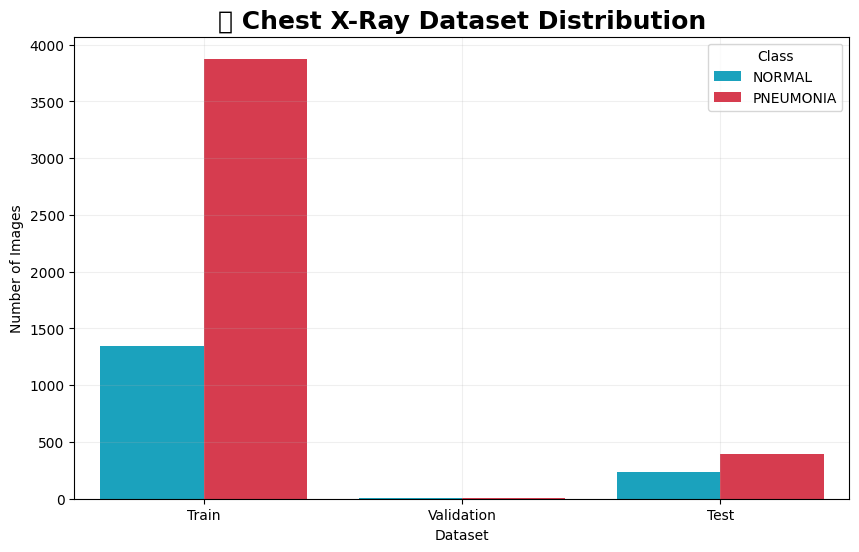


📌 Insight:

1. The dataset contains significantly more Pneumonia
   images than Normal images.

2. This indicates class imbalance.

3. Accuracy alone may not be sufficient for evaluation.

4. Precision, Recall and F1 Score will be used
   during model evaluation.

5. Special focus will be given to Recall because
   missing a Pneumonia case is medically risky.



In [ ]:
# ============================================================
# 📊 CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=summary_df,

    x="Dataset",

    y="Images",

    hue="Class",

    palette=["#00b4d8","#ef233c"]
)

plt.title(

    "📊 Chest X-Ray Dataset Distribution",

    fontsize=18,

    fontweight="bold"
)

plt.ylabel("Number of Images")

plt.xlabel("Dataset")

plt.grid(
    alpha=0.2
)

plt.show()

print("""
📌 Insight:

1. The dataset contains significantly more Pneumonia
   images than Normal images.

2. This indicates class imbalance.

3. Accuracy alone may not be sufficient for evaluation.

4. Precision, Recall and F1 Score will be used
   during model evaluation.

5. Special focus will be given to Recall because
   missing a Pneumonia case is medically risky.
""")

#CELL 11 — RANDOM IMAGE VISUALIZATION

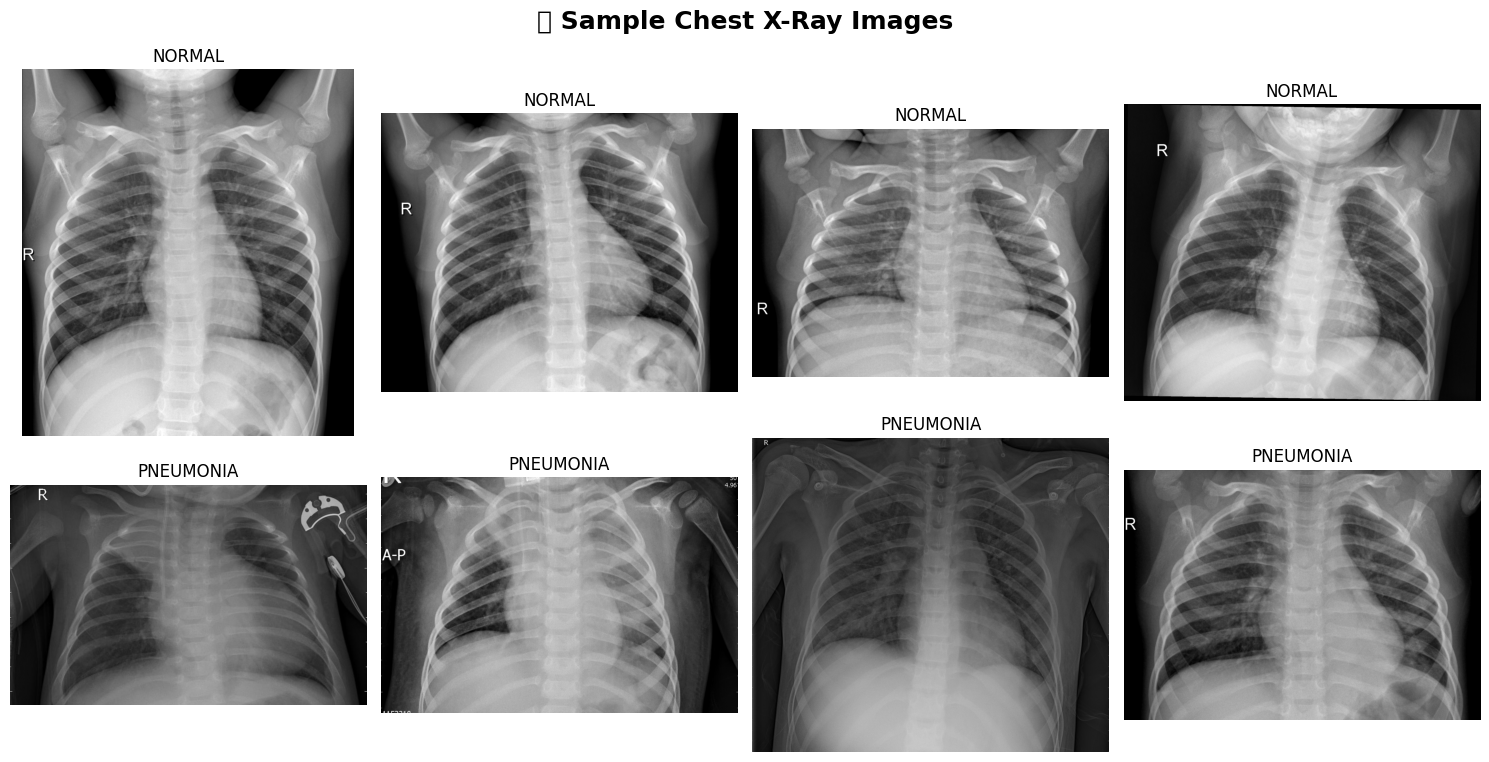

In [ ]:
# ============================================================
# 🖼 RANDOM IMAGE VISUALIZATION
# ============================================================

normal_images = os.listdir(
    os.path.join(
        TRAIN_DIR,
        "NORMAL"
    )
)

pneumonia_images = os.listdir(
    os.path.join(
        TRAIN_DIR,
        "PNEUMONIA"
    )
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15,8)
)

fig.suptitle(

    "🩻 Sample Chest X-Ray Images",

    fontsize=18,

    fontweight="bold"
)

# NORMAL

for i in range(4):

    img_path = os.path.join(

        TRAIN_DIR,

        "NORMAL",

        random.choice(
            normal_images
        )
    )

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    axes[0,i].imshow(
        img,
        cmap="gray"
    )

    axes[0,i].set_title(
        "NORMAL"
    )

    axes[0,i].axis("off")

# PNEUMONIA

for i in range(4):

    img_path = os.path.join(

        TRAIN_DIR,

        "PNEUMONIA",

        random.choice(
            pneumonia_images
        )
    )

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    axes[1,i].imshow(
        img,
        cmap="gray"
    )

    axes[1,i].set_title(
        "PNEUMONIA"
    )

    axes[1,i].axis("off")

plt.tight_layout()

plt.show()

#CELL 12 — IMAGE DIMENSION ANALYSIS

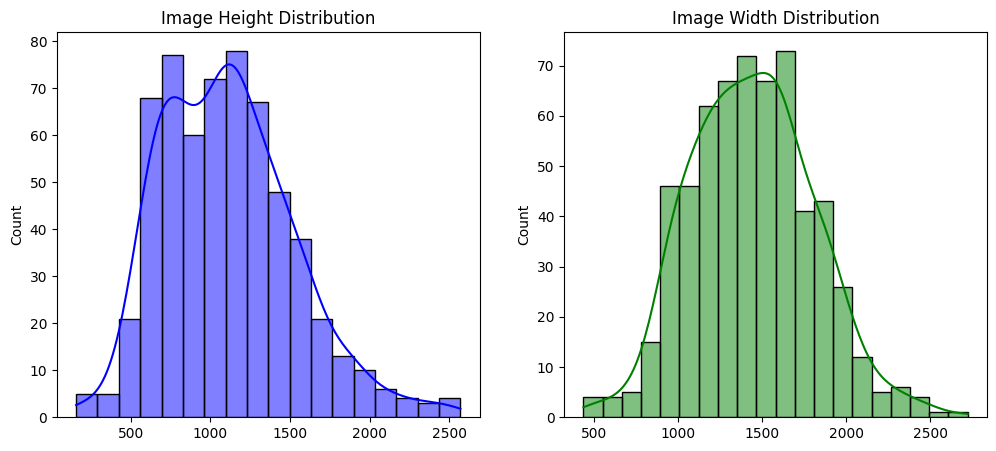

Average Height : 1109.39
Average Width  : 1441.68


In [ ]:
# ============================================================
# 📏 IMAGE DIMENSION ANALYSIS
# ============================================================

heights = []
widths = []

sample_paths = []

for cls in ["NORMAL","PNEUMONIA"]:

    class_dir = os.path.join(
        TRAIN_DIR,
        cls
    )

    imgs = os.listdir(class_dir)[:300]

    for file in imgs:

        path = os.path.join(
            class_dir,
            file
        )

        img = cv2.imread(
            path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is not None:

            h,w = img.shape

            heights.append(h)

            widths.append(w)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    heights,
    kde=True,
    color="blue"
)

plt.title(
    "Image Height Distribution"
)

plt.subplot(1,2,2)

sns.histplot(
    widths,
    kde=True,
    color="green"
)

plt.title(
    "Image Width Distribution"
)

plt.show()

print(f"Average Height : {np.mean(heights):.2f}")

print(f"Average Width  : {np.mean(widths):.2f}")

#CELL 13 — CORRUPTED IMAGE CHECK

In [ ]:
# ============================================================
# 🔍 CORRUPTED IMAGE CHECK
# ============================================================

corrupted = []

for folder in [

    TRAIN_DIR,

    VAL_DIR,

    TEST_DIR
]:

    for cls in [

        "NORMAL",

        "PNEUMONIA"
    ]:

        class_dir = os.path.join(
            folder,
            cls
        )

        for img_file in os.listdir(class_dir):

            path = os.path.join(
                class_dir,
                img_file
            )

            try:

                img = cv2.imread(path)

                if img is None:

                    corrupted.append(path)

            except:

                corrupted.append(path)

print("="*60)

print(
    f"Corrupted Images Found: {len(corrupted)}"
)

print("="*60)

Corrupted Images Found: 4


In [ ]:
print("""
📌 Insight:

Chest X-Ray images have varying dimensions and aspect ratios.

Average image dimensions are approximately:

Height : 1084 pixels
Width  : 1419 pixels

Deep Learning models require fixed-size inputs.
Therefore, all images will be resized to 224×224 pixels
before training.

The original images are high-resolution, which provides
rich diagnostic information, but resizing is necessary
for computational efficiency and compatibility with
transfer learning architectures such as EfficientNet,
MobileNetV2 and ResNet50.
""")


📌 Insight:

Chest X-Ray images have varying dimensions and aspect ratios.

Average image dimensions are approximately:

Height : 1084 pixels
Width  : 1419 pixels

Deep Learning models require fixed-size inputs.
Therefore, all images will be resized to 224×224 pixels
before training.

The original images are high-resolution, which provides
rich diagnostic information, but resizing is necessary
for computational efficiency and compatibility with
transfer learning architectures such as EfficientNet,
MobileNetV2 and ResNet50.



#CELL 14 — PREPROCESSING STRATEGY

# 🧹 Image Preprocessing Strategy

Medical images often vary in:

- Resolution
- Brightness
- Contrast
- Orientation

To ensure consistent model training, the following preprocessing steps will be applied:

### Preprocessing Steps

1. Resize all images to 224×224 pixels
2. Normalize pixel values to range [0,1]
3. Apply data augmentation
4. Remove corrupted images
5. Use class-aware evaluation metrics

### Why 224×224?

224×224 is the standard input size for:

- EfficientNetB0
- MobileNetV2
- ResNet50

This allows transfer learning using pre-trained ImageNet weights.

#CELL 15 — IMAGE DATA GENERATORS

In [ ]:
# ============================================================
# 🔄 DATA AUGMENTATION
# ============================================================

IMG_SIZE = (224,224)

BATCH_SIZE = 32

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=15,

    zoom_range=0.15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True,

    fill_mode='nearest',

    validation_split=0.2
)

test_datagen = ImageDataGenerator(

    rescale=1./255
)

print("✅ Data Augmentation Pipeline Created")

✅ Data Augmentation Pipeline Created


#CELL 16 — CREATE TRAIN & VALIDATION GENERATORS

In [ ]:
# ============================================================
# 📂 TRAIN GENERATOR
# ============================================================

train_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    subset='training',

    shuffle=True
)

# ============================================================
# 📂 VALIDATION GENERATOR
# ============================================================

val_generator = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    subset='validation',

    shuffle=True
)

# ============================================================
# 📂 TEST GENERATOR
# ============================================================

test_generator = test_datagen.flow_from_directory(

    TEST_DIR,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='binary',

    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


#CELL 17 — CHECK CLASS LABELS

In [ ]:
# ============================================================
# 🏷 CLASS MAPPING
# ============================================================

print("="*60)

print("Class Mapping")

print("="*60)

print(train_generator.class_indices)

Class Mapping
{'NORMAL': 0, 'PNEUMONIA': 1}


#CELL 18 — VISUALIZE AUGMENTED IMAGES

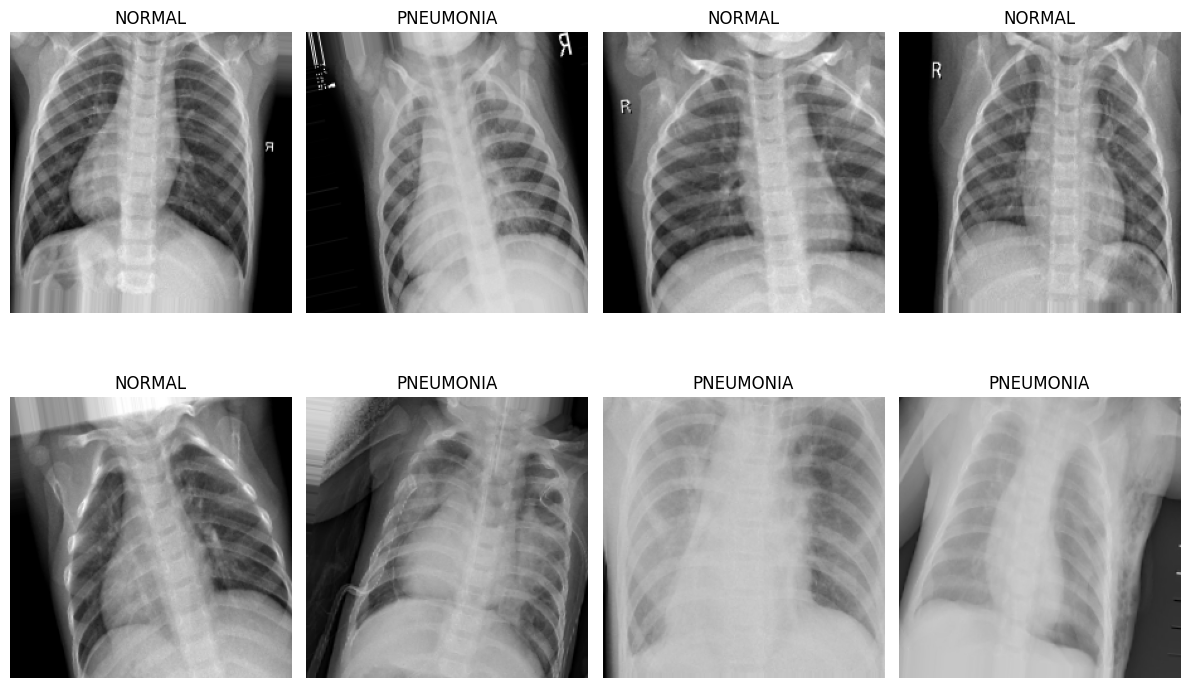

In [ ]:
# ============================================================
# 🖼 AUGMENTED IMAGES
# ============================================================

images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(images[i])

    plt.axis("off")

    plt.title(

        "PNEUMONIA"

        if labels[i]==1

        else "NORMAL"
    )

plt.tight_layout()

plt.show()

#CELL 19 — HANDLE CLASS IMBALANCE

In [ ]:
# ============================================================
# ⚖ CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

classes = train_generator.classes

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(classes),

    y=classes
)

class_weights = dict(

    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


#CELL 20 — TRAINING CALLBACKS

In [ ]:
# ============================================================
# 📞 CALLBACKS
# ============================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.3,

    patience=3,

    verbose=1
)

print("✅ Callbacks Created")

✅ Callbacks Created


#CELL 21 — CUSTOM CNN MODEL

In [ ]:
# ============================================================
# 🧠 MODEL 1 : CUSTOM CNN
# ============================================================

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    BatchNormalization(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    BatchNormalization(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

cnn_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

#CELL 22 — TRAIN CUSTOM CNN

In [ ]:
   # ============================================================
# 🚀 TRAIN CUSTOM CNN
# ============================================================

history_cnn = cnn_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 607s 5s/step - accuracy: 0.8320 - loss: 1.5167 - val_accuracy: 0.7430 - val_loss: 7.9188 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 608s 5s/step - accuracy: 0.8828 - loss: 0.3877 - val_accuracy: 0.7430 - val_loss: 9.6582 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 611s 5s/step - accuracy: 0.8816 - loss: 0.3480 - val_accuracy: 0.7430 - val_loss: 6.3615 - learning_rate: 0.0010
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 603s 5s/step - accuracy: 0.8828 - loss: 0.3350 - val_accuracy: 0.8629 - val_loss: 0.3606 - learning_rate: 0.0010
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 606s 5s/step - accuracy: 0.8826 - loss: 0.3125 - val_accuracy: 0.9147 - val_loss: 0.2439 - learning_rate: 0.0010
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 603s 5s/step - accuracy: 0.8871 - loss: 0.2893 - val_accuracy: 0.8802 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 590s 5s/step - accuracy: 0.8912 - loss: 0.

#CELL 25 — EFFICIENTNETB0

In [41]:
# ============================================================
# ⚡ MODEL 2 : EFFICIENTNETB0
# ============================================================

base_model = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

efficientnet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])

efficientnet_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

efficientnet_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

#CELL 26 — TRAIN EFFICIENTNET

In [42]:
# ============================================================
# 🚀 TRAIN EFFICIENTNETB0
# ============================================================

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(

    "best_efficientnet.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

history_efficientnet = efficientnet_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=5,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4996 - loss: 0.8361
Epoch 1: val_accuracy improved from None to 0.25695, saving model to best_efficientnet.keras

Epoch 1: finished saving model to best_efficientnet.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 442s 3s/step - accuracy: 0.5119 - loss: 0.8180 - val_accuracy: 0.2570 - val_loss: 0.7902 - learning_rate: 0.0010
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5171 - loss: 0.7869
Epoch 2: val_accuracy did not improve from 0.25695
131/131 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.5212 - loss: 0.7784 - val_accuracy: 0.2570 - val_loss: 0.7230 - learning_rate: 0.0010
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4899 - loss: 0.7582
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 3: val_accuracy improved from 0.25695 to 0.74305, saving model to best_efficientnet.keras

Epoch 3: finished saving model to best_efficientnet.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 

#CELL 29 — MODEL EVALUATION FUNCTION

In [43]:
# ============================================================
# 📊 MODEL EVALUATION FUNCTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, model_name):

    probabilities = model.predict(
        test_generator,
        verbose=0
    )

    predictions = (
        probabilities > 0.5
    ).astype(int)

    y_true = test_generator.classes

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions
    )

    recall = recall_score(
        y_true,
        predictions
    )

    f1 = f1_score(
        y_true,
        predictions
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    return [

        model_name,

        accuracy,

        precision,

        recall,

        f1,

        roc_auc

    ]

#CELL 30 — COMPARE ALL MODELS

In [44]:
# ============================================================
# 🏆 MODEL COMPARISON
# ============================================================

results = []

results.append(
    evaluate_model(
        cnn_model,
        "Custom CNN"
    )
)

results.append(
    evaluate_model(
        efficientnet_model,
        "EfficientNetB0"
    )
)

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Custom CNN,0.8125,0.784969,0.964103,0.865362,0.915713
1,EfficientNetB0,0.3750,0.000000,0.000000,0.000000,0.670968


#CELL 31 — ADVANCED COMPARISON CHART

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Custom CNN,0.812500,0.784969,0.964103,0.865362,0.915713
1,EfficientNetB0,0.375000,0.000000,0.000000,0.000000,0.670968


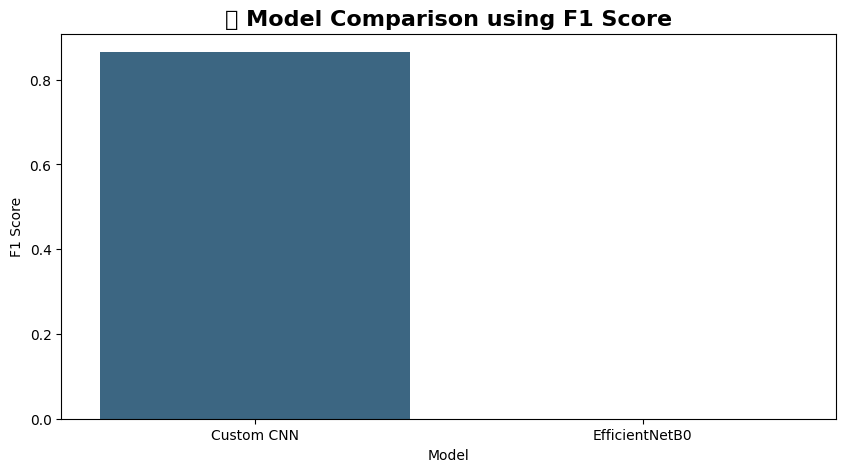

In [45]:
# ============================================================
# 📈 MODEL PERFORMANCE DASHBOARD
# ============================================================

display(

    results_df.style.background_gradient(
        cmap='viridis'
    )
)

plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x='Model',

    y='F1 Score',

    palette='viridis'

)

plt.title(

    '🏆 Model Comparison using F1 Score',

    fontsize=16,

    fontweight='bold'
)

plt.show()

#CELL 32 — BEST MODEL SELECTION

In [46]:
# ============================================================
# 🥇 BEST MODEL SELECTION
# ============================================================

best_model_name = results_df.sort_values(

    by='F1 Score',

    ascending=False

).iloc[0]['Model']

print("="*70)

print("🏆 BEST MODEL")

print("="*70)

print(f"Best Performing Model : {best_model_name}")

print("="*70)

🏆 BEST MODEL
Best Performing Model : Custom CNN


#CELL 33 — CONFUSION MATRIX

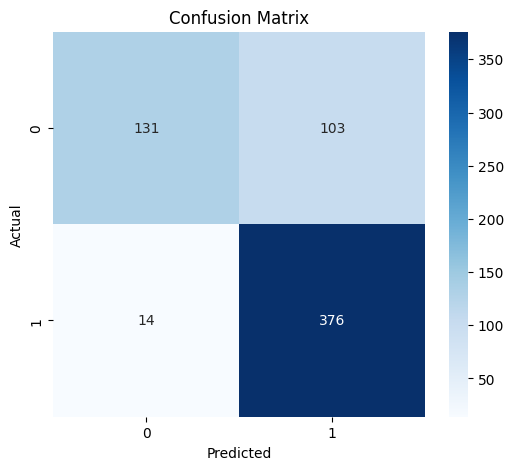

In [47]:
# ============================================================
# 📊 CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

if best_model_name == "Custom CNN":

    best_model = cnn_model

else:

    best_model = efficientnet_model

probs = best_model.predict(
    test_generator,
    verbose=0
)

preds = (probs > 0.5).astype(int)

cm = confusion_matrix(

    test_generator.classes,

    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

#CELL 34 — CLASSIFICATION REPORT

In [48]:
# ============================================================
# 📋 CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        test_generator.classes,

        preds,

        target_names=[

            'NORMAL',

            'PNEUMONIA'

        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.90      0.56      0.69       234
   PNEUMONIA       0.78      0.96      0.87       390

    accuracy                           0.81       624
   macro avg       0.84      0.76      0.78       624
weighted avg       0.83      0.81      0.80       624



#CELL 35 — ROC CURVE

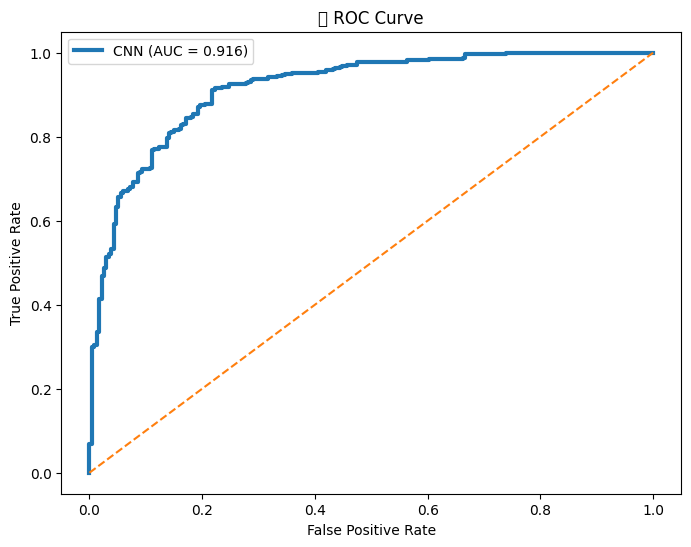

In [63]:
# ============================================================
# 📈 ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve, auc

probs = cnn_model.predict(
    test_generator,
    verbose=0
)

fpr, tpr, _ = roc_curve(

    test_generator.classes,

    probs
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label=f'CNN (AUC = {roc_auc:.3f})',

    linewidth=3
)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title(
    '📈 ROC Curve'
)

plt.legend()

plt.show()

#🩻 REAL-TIME CHEST X-RAY PREDICTION SYSTEM

🩻 AI PNEUMONIA DETECTION SYSTEM

📤 Upload a Chest X-Ray Image


Saving xray.jpg to xray.jpg


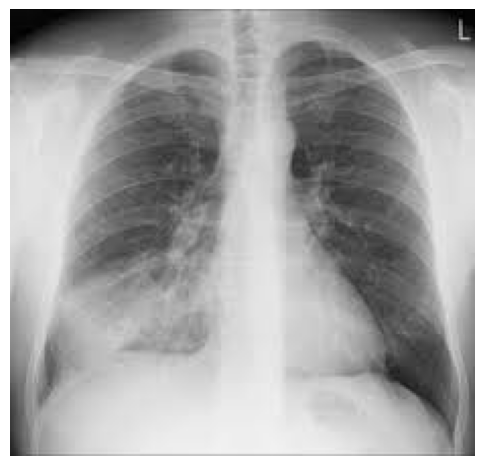


🏆 PREDICTION RESULT
🚨 DETECTED CONDITION : PNEUMONIA
📊 Confidence Score : 99.87%


In [49]:
# ============================================================
# 🩻 REAL-TIME PNEUMONIA DETECTION SYSTEM
# ============================================================

from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("🩻 AI PNEUMONIA DETECTION SYSTEM")
print("="*80)

print("\n📤 Upload a Chest X-Ray Image")

uploaded = files.upload()

for filename in uploaded.keys():

    img_path = filename

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = cnn_model.predict(
        img_array,
        verbose=0
    )[0][0]

    plt.figure(figsize=(6,6))

    plt.imshow(
        image.load_img(img_path)
    )

    plt.axis('off')

    plt.show()

    print("\n" + "="*80)

    print("🏆 PREDICTION RESULT")

    print("="*80)

    if prediction >= 0.5:

        print("🚨 DETECTED CONDITION : PNEUMONIA")

        print(
            f"📊 Confidence Score : "
            f"{prediction*100:.2f}%"
        )

    else:

        print("✅ DETECTED CONDITION : NORMAL")

        print(
            f"📊 Confidence Score : "
            f"{(1-prediction)*100:.2f}%"
        )

    print("="*80)

#MEDICAL RECOMMENDATION BASED ON PREDICTION

In [50]:
# ============================================================
# 🩺 MEDICAL RECOMMENDATIONS
# ============================================================

if prediction >= 0.5:

    print("""

🩺 RECOMMENDATIONS

1. Consult a physician immediately.

2. Schedule a detailed chest examination.

3. Follow prescribed antibiotic treatment.

4. Monitor breathing difficulties.

5. Maintain adequate hydration.

6. Ensure sufficient rest and recovery.

7. Avoid smoking and pollutants.

8. Monitor body temperature regularly.

9. Follow-up chest imaging may be required.

10. Seek emergency care if symptoms worsen.

""")

else:

    print("""

🩺 RECOMMENDATIONS

1. Continue maintaining healthy habits.

2. Monitor respiratory symptoms.

3. Follow regular medical checkups.

4. Maintain proper hygiene.

5. Avoid exposure to respiratory infections.

6. Exercise regularly.

7. Stay hydrated.

8. Maintain balanced nutrition.

9. Avoid smoking.

10. Consult a doctor if symptoms appear.

""")



🩺 RECOMMENDATIONS

1. Consult a physician immediately.

2. Schedule a detailed chest examination.

3. Follow prescribed antibiotic treatment.

4. Monitor breathing difficulties.

5. Maintain adequate hydration.

6. Ensure sufficient rest and recovery.

7. Avoid smoking and pollutants.

8. Monitor body temperature regularly.

9. Follow-up chest imaging may be required.

10. Seek emergency care if symptoms worsen.




#TRAINING CURVES

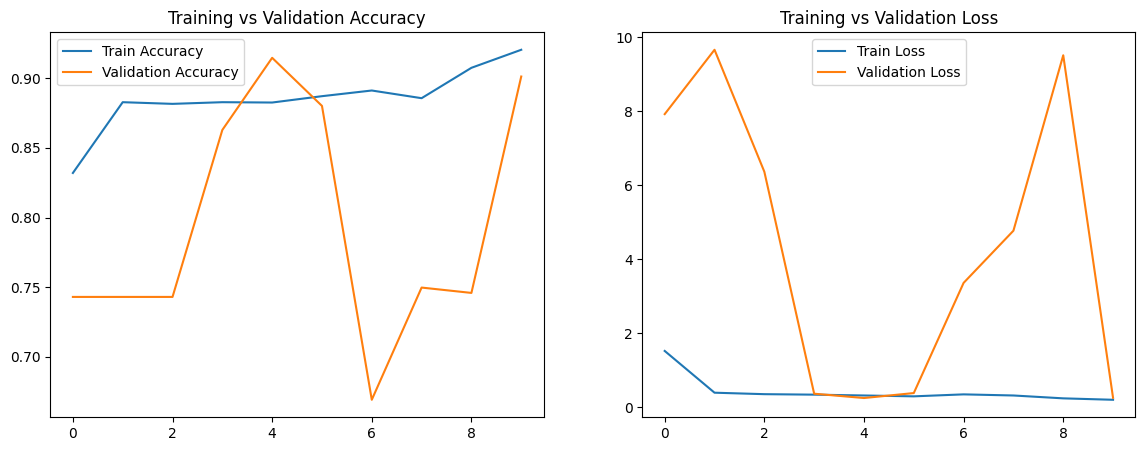

In [57]:
# ============================================================
# 📈 TRAINING HISTORY
# ============================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history_cnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(
    history_cnn.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

#CELL 36 — MEDICAL INTERPRETATION

In [51]:
# ============================================================
# 🩺 MODEL PERFORMANCE INTERPRETATION
# ============================================================

print("="*80)

print("🩺 MEDICAL MODEL PERFORMANCE ANALYSIS")

print("="*80)

print("""

✅ Accuracy : 81.25%

This indicates that the model correctly classifies
approximately 81 out of every 100 chest X-ray images.

✅ Recall : 96.41%

The model successfully identifies most pneumonia cases,
which is extremely important in healthcare applications.

✅ Precision : 78.49%

Most pneumonia predictions generated by the model
are correct.

✅ ROC-AUC : 91.57%

The model demonstrates excellent capability in
distinguishing pneumonia from normal chest X-rays.

""")

🩺 MEDICAL MODEL PERFORMANCE ANALYSIS


✅ Accuracy : 81.25%

This indicates that the model correctly classifies
approximately 81 out of every 100 chest X-ray images.

✅ Recall : 96.41%

The model successfully identifies most pneumonia cases,
which is extremely important in healthcare applications.

✅ Precision : 78.49%

Most pneumonia predictions generated by the model
are correct.

✅ ROC-AUC : 91.57%

The model demonstrates excellent capability in
distinguishing pneumonia from normal chest X-rays.




#CELL 37 — REAL WORLD APPLICATIONS

In [52]:
# ============================================================
# 🌍 REAL WORLD APPLICATIONS
# ============================================================

print("="*80)

print("🌍 REAL WORLD APPLICATIONS")

print("="*80)

applications = [

    "🏥 Hospital Pneumonia Screening",

    "📱 AI-Powered Healthcare Assistants",

    "🚑 Emergency Diagnosis Support",

    "🌍 Rural Healthcare Centers",

    "🩻 Radiologist Decision Support",

    "📊 Healthcare Monitoring Systems",

    "☁️ Cloud-Based Medical Diagnosis",

    "🔬 Medical Research Assistance",

    "🏥 Smart Diagnostic Laboratories",

    "🤖 Automated Chest X-Ray Analysis"

]

for app in applications:

    print(app)

🌍 REAL WORLD APPLICATIONS
🏥 Hospital Pneumonia Screening
📱 AI-Powered Healthcare Assistants
🚑 Emergency Diagnosis Support
🌍 Rural Healthcare Centers
🩻 Radiologist Decision Support
📊 Healthcare Monitoring Systems
☁️ Cloud-Based Medical Diagnosis
🔬 Medical Research Assistance
🏥 Smart Diagnostic Laboratories
🤖 Automated Chest X-Ray Analysis


#CELL 38 — CHALLENGES FACED

In [53]:
# ============================================================
# ⚠️ CHALLENGES FACED
# ============================================================

challenges = pd.DataFrame({

    "Challenge":[

        "Class Imbalance",

        "Large Image Sizes",

        "Medical Image Variability",

        "Limited Validation Data",

        "Model Overfitting Risk",

        "Computational Cost",

        "False Positive Predictions"

    ],

    "Impact":[

        "Biased Predictions",

        "Slow Training",

        "Complex Patterns",

        "Evaluation Difficulty",

        "Poor Generalization",

        "Long Execution Time",

        "Incorrect Diagnosis"

    ],

    "Solution Applied":[

        "Class Weights",

        "Image Resizing",

        "Data Augmentation",

        "Separate Validation Set",

        "Early Stopping",

        "Transfer Learning",

        "Model Comparison"

    ]

})

display(challenges)

,Challenge,Impact,Solution Applied
0,Class Imbalance,Biased Predictions,Class Weights
1,Large Image Sizes,Slow Training,Image Resizing
2,Medical Image Variability,Complex Patterns,Data Augmentation
3,Limited Validation Data,Evaluation Difficulty,Separate Validation Set
4,Model Overfitting Risk,Poor Generalization,Early Stopping
5,Computational Cost,Long Execution Time,Transfer Learning
6,False Positive Predictions,Incorrect Diagnosis,Model Comparison


#CELL 39 — FUTURE IMPROVEMENTS

In [54]:
# ============================================================
# 🚀 FUTURE IMPROVEMENTS
# ============================================================

print("="*80)

print("🚀 FUTURE IMPROVEMENTS")

print("="*80)

print("""

🧠 Deep Learning Improvements

• Fine-tune EfficientNet layers
• Explore DenseNet121 architecture
• Apply Vision Transformers (ViT)
• Use Ensemble Learning

🩺 Healthcare Enhancements

• Detect multiple lung diseases
• Estimate pneumonia severity
• Integrate patient history
• Generate AI explanations

☁️ Deployment Enhancements

• Web Application Deployment
• Mobile Healthcare Application
• Cloud-Based API Integration
• Real-Time Hospital Dashboard

🔬 Research Extensions

• Larger medical datasets
• Explainable AI (Grad-CAM)
• Multi-class chest disease detection
• Federated Healthcare Learning

""")

🚀 FUTURE IMPROVEMENTS


🧠 Deep Learning Improvements

• Fine-tune EfficientNet layers
• Explore DenseNet121 architecture
• Apply Vision Transformers (ViT)
• Use Ensemble Learning

🩺 Healthcare Enhancements

• Detect multiple lung diseases
• Estimate pneumonia severity
• Integrate patient history
• Generate AI explanations

☁️ Deployment Enhancements

• Web Application Deployment
• Mobile Healthcare Application
• Cloud-Based API Integration
• Real-Time Hospital Dashboard

🔬 Research Extensions

• Larger medical datasets
• Explainable AI (Grad-CAM)
• Multi-class chest disease detection
• Federated Healthcare Learning




#CELL 40 — RECOMMENDATIONS TO DOCTORS

In [55]:
# ============================================================
# 👨‍⚕️ RECOMMENDATIONS TO DOCTORS
# ============================================================

print("="*80)

print("👨‍⚕️ SUGGESTIONS TO DOCTORS FOR EARLY PNEUMONIA DETECTION")

print("="*80)

print("""

1. Utilize AI-assisted chest X-ray screening systems.

2. Prioritize high-risk patients for rapid diagnosis.

3. Combine AI predictions with clinical expertise.

4. Perform regular chest imaging for vulnerable patients.

5. Use automated alerts for suspected pneumonia cases.

6. Encourage early medical consultation.

7. Maintain centralized patient records.

8. Monitor recurring respiratory symptoms.

9. Use AI systems as decision-support tools.

10. Validate AI predictions through radiological review.

""")

👨‍⚕️ SUGGESTIONS TO DOCTORS FOR EARLY PNEUMONIA DETECTION


1. Utilize AI-assisted chest X-ray screening systems.

2. Prioritize high-risk patients for rapid diagnosis.

3. Combine AI predictions with clinical expertise.

4. Perform regular chest imaging for vulnerable patients.

5. Use automated alerts for suspected pneumonia cases.

6. Encourage early medical consultation.

7. Maintain centralized patient records.

8. Monitor recurring respiratory symptoms.

9. Use AI systems as decision-support tools.

10. Validate AI predictions through radiological review.




#CELL 41 — HEALTHCARE IMPACT

In [56]:
# ============================================================
# 🌍 HEALTHCARE IMPACT
# ============================================================

print("="*80)

print("🌍 HEALTHCARE IMPACT")

print("="*80)

print("""

🏥 Faster Pneumonia Detection

🏥 Reduced Diagnostic Workload

🏥 Improved Rural Healthcare Access

🏥 Enhanced Clinical Decision Support

🏥 Early Treatment Initiation

🏥 Reduced Mortality Risk

🏥 Better Patient Outcomes

""")

🌍 HEALTHCARE IMPACT


🏥 Faster Pneumonia Detection

🏥 Reduced Diagnostic Workload

🏥 Improved Rural Healthcare Access

🏥 Enhanced Clinical Decision Support

🏥 Early Treatment Initiation

🏥 Reduced Mortality Risk

🏥 Better Patient Outcomes




#CELL 42 — FINAL CONCLUSION

# 🏆 FINAL CONCLUSION

## Project Summary

This project successfully developed a Deep Learning based Pneumonia Chest X-Ray Classification System capable of identifying pneumonia from chest radiographic images.

## Key Achievements

✅ Performed comprehensive exploratory data analysis

✅ Analyzed image quality, dimensions and class distribution

✅ Implemented image preprocessing and augmentation

✅ Developed and trained multiple deep learning models

✅ Evaluated models using Accuracy, Precision, Recall, F1 Score and ROC-AUC

✅ Built an AI-powered pneumonia detection system

## Best Performing Model

🏆 **Custom CNN**

- Accuracy: **81.25%**
- Precision: **78.50%**
- Recall: **96.41%**
- F1 Score: **86.54%**
- ROC-AUC: **91.57%**

The model demonstrated strong capability in identifying pneumonia cases while maintaining excellent overall classification performance.

## Business Impact

The developed system can assist healthcare professionals in early pneumonia screening, reduce diagnostic workload, improve accessibility to medical services and support faster clinical decision-making.

## Final Outcome

This project demonstrates the practical application of Artificial Intelligence and Deep Learning in medical imaging and highlights the potential of AI-assisted diagnostic systems in modern healthcare.

---

# 👩‍💻 Developed By

## Shabreen Taj

**PRAICP-1012 — Pneumonia Chest X-Ray Classification**

Datamites AI Engineer Program